# Proyecto Final  
## Sistema de Recuperación de Información Multimodal con RAG  
**Asignatura:** Recuperación de Información  
**Realizado por:** Bautista Alexis, Correa Adrian, Yunga Bryan  
**Fecha de entrega:** 22 de julio de 2026

### **Objetivo**
Diseñar e implementar un sistema de Recuperación de Información Multimodal capaz de responder consultas conversacionales sobre un corpus compuesto por texto e imágenes.

El sistema deberá utilizar modelos de embeddings multimodales para representar el contenido del corpus, almacenar dichas representaciones en una base de datos vectorial, recuperar los elementos más relevantes para una consulta y utilizarlos como contexto para un sistema de Retrieval-Augmented Generation (RAG).

El objetivo del proyecto es integrar los conceptos estudiados durante el curso en un sistema moderno de Recuperación de Información, combinando recuperación multimodal, bases de datos vectoriales, modelos de lenguaje, interfaces conversacionales y evaluación experimental.

## Alcance y funcionalidades mínimas

### a. Preparación del corpus

Cargando URLs de imágenes (Crossing Minds)...
Cargando textos originales (Amazon ESCI)...
Total de productos fusionados con texto e imagen URL: 35839
Descargando y asociando 5 muestras...
Registros multimodales listos: 4
--- RESULTADO DE LA ASOCIACIÓN MULTIMODAL ---
ID del Producto: 0007589042
Texto procesado (Contexto): 'big nate series collection lincoln peirce 6 books box set gift pack big nate on a roll, goes for broke, the boy with the biggest head in the world, st...'
Objeto de Imagen: <class 'PIL.Image.Image'> - Tamaño: (306, 466)


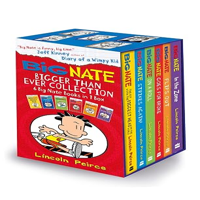

In [2]:
from preparar_corpus import cargar_y_fusionar_corpus, asociar_multimodal

# Cargar y fusionar el corpus
df_corpus = cargar_y_fusionar_corpus(split="train")
print(f"Total de productos fusionados con texto e imagen URL: {len(df_corpus)}")

# Procesar texto y asociar imágenes
# Extraemos una muestra pequeña para no saturar las descargas en la fase de prueba
corpus_preparado = asociar_multimodal(df_corpus, num_muestras=5)
print(f"Registros multimodales listos: {len(corpus_preparado)}")

# Mostrar resultados
if corpus_preparado:
    muestra = corpus_preparado[0]
    print("--- RESULTADO DE LA ASOCIACIÓN MULTIMODAL ---")
    print(f"ID del Producto: {muestra['product_id']}")
    # Aquí es donde veremos el texto real que usará el RAG
    print(f"Texto procesado (Contexto): '{muestra['texto'][:150]}...'") 
    print(f"Objeto de Imagen: {type(muestra['imagen'])} - Tamaño: {muestra['imagen'].size}")
    
    # Previsualización rápida
    display(muestra['imagen'].resize((200, 200)))
else:
    print("No se pudieron asociar imágenes válidas en esta muestra.")

## 2. Construcción de representaciones vectoriales

El sistema utiliza un modelo multimodal basado en **CLIP** (`openai/clip-vit-base-patch32`) para generar embeddings que representan texto e imágenes en un mismo espacio vectorial. Esto permite comparar consultas textuales del usuario contra los documentos del corpus (título + descripción + imagen del producto).

El proceso consta de tres etapas:

1. **Embeddings del corpus**: para cada producto se generan por separado el embedding de su texto y el de su imagen; ambos se combinan (promedio normalizado) en un único vector multimodal por documento.
2. **Embeddings de consulta**: las consultas del usuario, al ser texto, se vectorizan con el mismo encoder de texto de CLIP, quedando en el mismo espacio que los documentos.
3. **Almacenamiento**: los vectores del corpus se indexan con **FAISS** (búsqueda por similitud coseno) y se guardan en disco junto con sus metadatos (`product_id`, texto) para poder reutilizarlos sin recalcular los embeddings en cada ejecución.


In [ ]:
from preparar_corpus import cargar_y_fusionar_corpus, asociar_multimodal
from construir_embeddings import ConstructorEmbeddings

# 1. Corpus (esto ya lo tenías)
df = cargar_y_fusionar_corpus(split="train")
datos = asociar_multimodal(df, num_muestras=500)

# 2. Embeddings multimodales
constructor = ConstructorEmbeddings()
constructor.construir_base_vectorial(datos)
constructor.guardar("vector_store")   # queda en disco para reutilizar

# 3. Simular una consulta de usuario
resultados = constructor.buscar("zapatillas rojas para correr", top_k=5)
for r in resultados:
    print(r["score"], r["product_id"], r["texto"][:80])